# Import and Loaded Dataset


In [3]:
#import libraries
import numpy as np
import pandas as pd
import nltk
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import warnings
warnings.filterwarnings('ignore')

# download necessary packege
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
df = pd.read_csv('Musical_instruments_reviews.csv')
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...","[0, 0]","Not much to write about here, but it does exac...",5,good,1393545600,"02 28, 2014"
1,A14VAT5EAX3D9S,1384719342,Jake,"[13, 14]",The product does exactly as it should and is q...,5,Jake,1363392000,"03 16, 2013"
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""","[1, 1]",The primary job of this device is to block the...,5,It Does The Job Well,1377648000,"08 28, 2013"
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""","[0, 0]",Nice windscreen protects my MXL mic and preven...,5,GOOD WINDSCREEN FOR THE MONEY,1392336000,"02 14, 2014"
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,"[0, 0]",This pop filter is great. It looks and perform...,5,No more pops when I record my vocals.,1392940800,"02 21, 2014"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10261 entries, 0 to 10260
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   reviewerID      10261 non-null  object
 1   asin            10261 non-null  object
 2   reviewerName    10234 non-null  object
 3   helpful         10261 non-null  object
 4   reviewText      10254 non-null  object
 5   overall         10261 non-null  int64 
 6   summary         10261 non-null  object
 7   unixReviewTime  10261 non-null  int64 
 8   reviewTime      10261 non-null  object
dtypes: int64(2), object(7)
memory usage: 721.6+ KB


# Text Preprocessing

In [4]:
# Handle missing values
df['reviewText'] = df['reviewText'].fillna('')

# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenize
    tokens = nltk.word_tokenize(text)
    # Remove stop words and lemmatize
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    # Join tokens back to string
    return ' '.join(cleaned_tokens)

# Apply preprocessing to the reviewText column
df['cleaned_reviewText'] = df['reviewText'].apply(preprocess_text)

# Display the first few rows with the new column
display(df[['reviewText', 'cleaned_reviewText']].head())

,reviewText,cleaned_reviewText
0,"Not much to write about here, but it does exac...",much write exactly supposed filter pop sound r...
1,The product does exactly as it should and is q...,product exactly quite affordablei realized dou...
2,The primary job of this device is to block the...,primary job device block breath would otherwis...
3,Nice windscreen protects my MXL mic and preven...,nice windscreen protects mxl mic prevents pop ...
4,This pop filter is great. It looks and perform...,pop filter great look performs like studio fil...


In [5]:
df['reviewText']

0        Not much to write about here, but it does exac...
1        The product does exactly as it should and is q...
2        The primary job of this device is to block the...
3        Nice windscreen protects my MXL mic and preven...
4        This pop filter is great. It looks and perform...
                               ...                        
10256              Great, just as expected.  Thank to all.
10257    I've been thinking about trying the Nanoweb st...
10258    I have tried coated strings in the past ( incl...
10259    Well, MADE by Elixir and DEVELOPED with Taylor...
10260    These strings are really quite good, but I wou...
Name: reviewText, Length: 10261, dtype: object

## Sentiment labeling

Determine the sentiment of each review based on the `overall` rating. We can consider ratings above a certain threshold as positive, below another threshold as negative, and in between as neutral.



In [6]:
def get_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating <= 2:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_label'] = df['overall'].apply(get_sentiment)

display(df['sentiment_label'].value_counts())

sentiment_label
positive    9022
neutral      772
negative     467
Name: count, dtype: int64

## Feature extraction


Convert the preprocessed text data into numerical features using methods like TF-IDF


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
tfidf_features = tfidf_vectorizer.fit_transform(df['cleaned_reviewText'])

print(tfidf_features.shape)

(10261, 29635)


## Model building

Train machine learning models Naive Bayes, SVM on the extracted features and sentiment labels.


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(tfidf_features, df['sentiment_label'], test_size=0.2, random_state=42)

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Model evaluation

Evaluate the performance of the trained models using appropriate metrics such as accuracy, precision, and recall.


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nb_predictions = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_precision = precision_score(y_test, nb_predictions, average='weighted')
nb_recall = recall_score(y_test, nb_predictions, average='weighted')
nb_f1 = f1_score(y_test, nb_predictions, average='weighted')

print("Multinomial Naive Bayes Model Evaluation:")
print(f"Accuracy: {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall: {nb_recall:.4f}")
print(f"F1-score: {nb_f1:.4f}")

Multinomial Naive Bayes Model Evaluation:
Accuracy: 0.8811
Precision: 0.7764
Recall: 0.8811
F1-score: 0.8255


In [10]:
svm_predictions = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions, average='weighted')
svm_recall = recall_score(y_test, svm_predictions, average='weighted')
svm_f1 = f1_score(y_test, svm_predictions, average='weighted')

print("\nSVM Model Evaluation:")
print(f"Accuracy: {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall: {svm_recall:.4f}")
print(f"F1-score: {svm_f1:.4f}")


SVM Model Evaluation:
Accuracy: 0.8836
Precision: 0.8972
Recall: 0.8836
F1-score: 0.8313


# user interface

In [11]:
import gradio as gr

def predict_sentiment(text):
    # Preprocess the input text
    cleaned_text = preprocess_text(text)
    # Vectorize the cleaned text
    text_features = tfidf_vectorizer.transform([cleaned_text])
    # Predict the sentiment using the trained SVM model
    prediction = nb_model.predict(text_features)
    return prediction[0]

# Create the Gradio interface
iface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=2, placeholder="Enter review text here..."),
    outputs="text",
    title="Sentiment Analysis of Musical Instrument Reviews",
    description="Enter a review to get a sentiment prediction (positive, neutral, or negative)."
)

# Launch the interface
iface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


### Key Findings
The model demonstrates an overall accuracy of 88%; however, its predictions appear to be biased toward the positive class. In practice, when neutral or negative messages are provided as input, the model still tends to classify them as positive. 

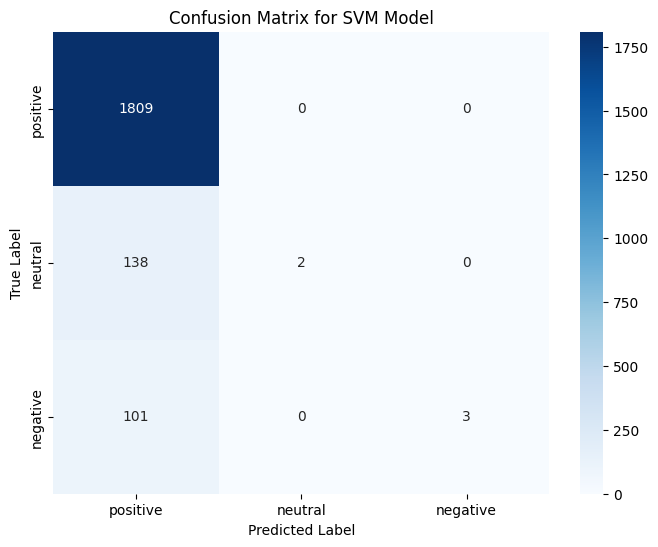

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix for the SVM model
conf_matrix = confusion_matrix(y_test, svm_predictions, labels=['positive', 'neutral', 'negative'])

# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['positive', 'neutral', 'negative'], yticklabels=['positive', 'neutral', 'negative'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Model')
plt.show()

The model is heavily biased toward predicting the positive sentiment. Despite showing an overall high accuracy (mainly due to the large number of positive samples), its performance for neutral and negative sentiments is very poor. This suggests a strong class imbalance or insufficient feature differentiation between sentiments.

# Oversample the minority classes


In [13]:
display(y_train.value_counts())


sentiment_label
positive    7213
neutral      632
negative     363
Name: count, dtype: int64

In [14]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

display(y_resampled.value_counts())

sentiment_label
positive    7213
neutral     7213
negative    7213
Name: count, dtype: int64

# Retrain models

In [15]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

nb_model_resampled = MultinomialNB()
nb_model_resampled.fit(X_resampled, y_resampled)

svm_model_resampled = SVC(kernel='linear')
svm_model_resampled.fit(X_resampled, y_resampled)

print("Models retrained using oversampled data.")

Models retrained using oversampled data.


# Evaluate retrained models



In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate retrained Multinomial Naive Bayes model
nb_resampled_predictions = nb_model_resampled.predict(X_test)

nb_resampled_accuracy = accuracy_score(y_test, nb_resampled_predictions)
nb_resampled_precision = precision_score(y_test, nb_resampled_predictions, average='weighted')
nb_resampled_recall = recall_score(y_test, nb_resampled_predictions, average='weighted')
nb_resampled_f1 = f1_score(y_test, nb_resampled_predictions, average='weighted')

print("Retrained Multinomial Naive Bayes Model Evaluation:")
print(f"Accuracy: {nb_resampled_accuracy:.4f}")
print(f"Precision: {nb_resampled_precision:.4f}")
print(f"Recall: {nb_resampled_recall:.4f}")
print(f"F1-score: {nb_resampled_f1:.4f}")

# Evaluate retrained SVM model
svm_resampled_predictions = svm_model_resampled.predict(X_test)

svm_resampled_accuracy = accuracy_score(y_test, svm_resampled_predictions)
svm_resampled_precision = precision_score(y_test, svm_resampled_predictions, average='weighted')
svm_resampled_recall = recall_score(y_test, svm_resampled_predictions, average='weighted')
svm_resampled_f1 = f1_score(y_test, svm_resampled_predictions, average='weighted')

print("\nRetrained SVM Model Evaluation:")
print(f"Accuracy: {svm_resampled_accuracy:.4f}")
print(f"Precision: {svm_resampled_precision:.4f}")
print(f"Recall: {svm_resampled_recall:.4f}")
print(f"F1-score: {svm_resampled_f1:.4f}")

Retrained Multinomial Naive Bayes Model Evaluation:
Accuracy: 0.7589
Precision: 0.8587
Recall: 0.7589
F1-score: 0.7983

Retrained SVM Model Evaluation:
Accuracy: 0.8334
Precision: 0.8440
Recall: 0.8334
F1-score: 0.8357


# User Interface

In [17]:
import gradio as gr

def predict_sentiment(text):
    # Preprocess the input text
    cleaned_text = preprocess_text(text)
    # Vectorize the cleaned text
    text_features = tfidf_vectorizer.transform([cleaned_text])
    # Predict the sentiment using the trained SVM model
    prediction = svm_model_resampled.predict(text_features)
    return prediction[0]

# Create the Gradio interface
iface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=2, placeholder="Enter review text here..."),
    outputs="text",
    title="Sentiment Analysis of Musical Instrument Reviews",
    description="Enter a review to get a sentiment prediction (positive, neutral, or negative)."
)

# Launch the interface
iface.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


# confusion matrix retrain model

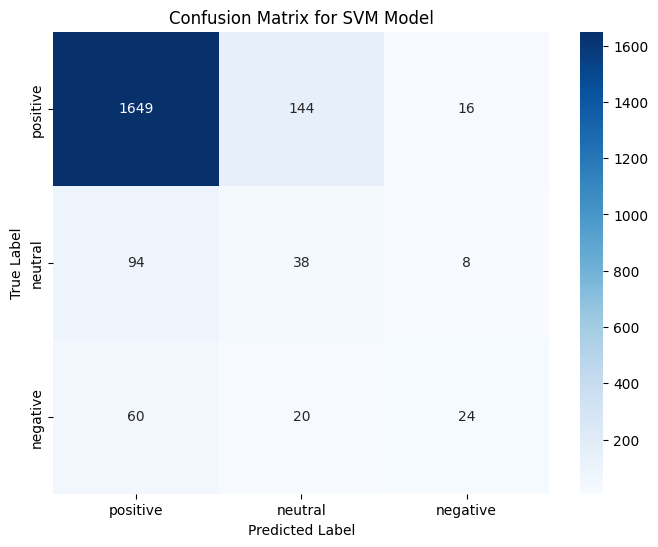

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix for the SVM model
conf_matrix = confusion_matrix(y_test,  svm_resampled_predictions, labels=['positive', 'neutral', 'negative'])

# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['positive', 'neutral', 'negative'], yticklabels=['positive', 'neutral', 'negative'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Model')
plt.show()

# Hyperparameter tune the retrained svm model

In [19]:
#Define parameter grid
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

In [20]:
#Choose cross-validation strategy
from sklearn.model_selection import StratifiedKFold

# Choose StratifiedKFold due to class imbalance
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Cross-validation strategy selected: {type(cv_strategy).__name__}")
print(f"Number of splits: {cv_strategy.get_n_splits(X_resampled, y_resampled)}")

Cross-validation strategy selected: StratifiedKFold
Number of splits: 5


In [21]:
#Perform hyperparameter tuning
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(svm_model_resampled, param_grid, cv=cv_strategy, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_resampled, y_resampled)

print("Best hyperparameters found:")
print(grid_search.best_params_)
print("Best cross-validation F1-weighted score:")
print(grid_search.best_score_)

Best hyperparameters found:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation F1-weighted score:
0.9995839964026333


### Save the best model for future use

In [22]:
import joblib

# Save the best model
joblib.dump(grid_search.best_estimator_, 'best_model.pkl')

# Later: load it back
loaded_model = joblib.load('best_model.pkl')

In [23]:
#save the whole GridSearchCV object
joblib.dump(grid_search, 'full_gridsearch.pkl')

# Load again
loaded_search = joblib.load('full_gridsearch.pkl')

# Access best model
best_model = loaded_search.best_estimator_

In [24]:
#Verify Loaded Model Works
y_pred = best_model.predict(X_test)
print("Predictions:", y_pred[:5])


Predictions: ['positive' 'positive' 'positive' 'positive' 'positive']


Tuned SVM Model Evaluation:
Accuracy: 0.8836
Precision: 0.8638
Recall: 0.8836
F1-score: 0.8324


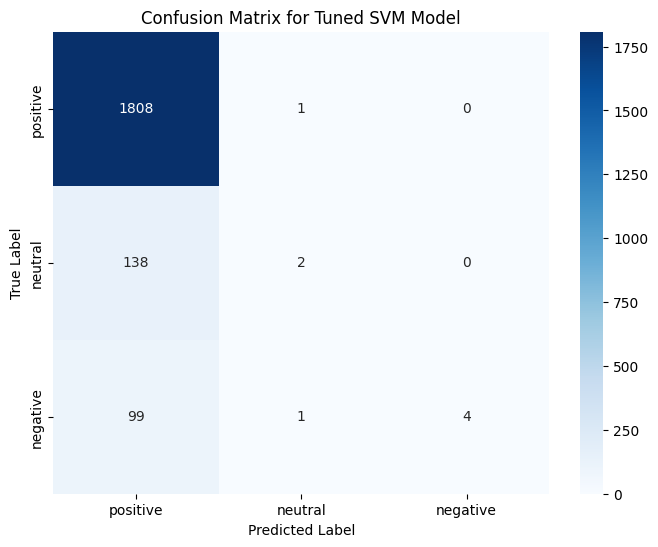

In [25]:
# Evaluate Tuned Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best model from the grid search
best_svm_model = grid_search.best_estimator_

# Make predictions on the test set
tuned_svm_predictions = best_svm_model.predict(X_test)

# Evaluate the tuned SVM model
tuned_svm_accuracy = accuracy_score(y_test, tuned_svm_predictions)
tuned_svm_precision = precision_score(y_test, tuned_svm_predictions, average='weighted')
tuned_svm_recall = recall_score(y_test, tuned_svm_predictions, average='weighted')
tuned_svm_f1 = f1_score(y_test, tuned_svm_predictions, average='weighted')

print("Tuned SVM Model Evaluation:")
print(f"Accuracy: {tuned_svm_accuracy:.4f}")
print(f"Precision: {tuned_svm_precision:.4f}")
print(f"Recall: {tuned_svm_recall:.4f}")
print(f"F1-score: {tuned_svm_f1:.4f}")

# Display confusion matrix for the tuned model
conf_matrix_tuned = confusion_matrix(y_test, tuned_svm_predictions, labels=['positive', 'neutral', 'negative'])

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=['positive', 'neutral', 'negative'], yticklabels=['positive', 'neutral', 'negative'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned SVM Model')
plt.show()

In [26]:
import gradio as gr

def predict_sentiment(text):
    # Preprocess the input text
    cleaned_text = preprocess_text(text)
    # Vectorize the cleaned text
    text_features = tfidf_vectorizer.transform([cleaned_text])
    # Predict the sentiment using the trained SVM model
    prediction = loaded_model.predict(text_features)
    return prediction[0]

# Create the Gradio interface
iface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=2, placeholder="Enter review text here..."),
    outputs="text",
    title="Sentiment Analysis of Musical Instrument Reviews",
    description="Enter a review to get a sentiment prediction (positive, neutral, or negative)."
)

# Launch the interface
iface.launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.
